In [2]:
import time
import numpy as np
import mujoco
# import mujoco.viewer
import pickle
import copy
import scipy
import scipy.signal


In [41]:

from sim.pid_controller import PIDController

xml_path = "/home/clown2/Desktop/Work/Research/afil-project/sim/block_model.xml"

model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

start_pose = np.array([1.0, 1.0, 1.0])  # x, z, y
target_pose = np.array([0.0, 0.0, 0.0])

centered_pos = copy.deepcopy(target_pose)

data.qpos[:] = start_pose.copy()
mujoco.mj_forward(model, data)

kp = [2., 5., 1.] 
# ki = [5.0, 50.0, 5.0]  
ki = [0., 0., 0.]    
# kd = [1.0, 2.0, 1.0]  
kd = [0., 0., 0.]

dt = model.opt.timestep
pid = PIDController(kp, ki, kd, dt, windup_limit=10.0) 

sim_time = 200.0 
num_steps = int(sim_time / dt)

body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "block")
mass = model.body_mass[body_id]
print(f"block mass: {mass} kg")

simulation_data = {
    'time': [],
    'position': [], 
    'velocity': [],
    'acceleration': [],
    'control': [],
    'target': []
}
    
for step in range(num_steps):
    
    t = data.time

    # chirp = lambda t: scipy.signal.chirp(t%20, f0=0.1, f1=1, t1=20, method='linear')

    # ang_chirp = lambda t: scipy.signal.chirp(t%20, f0=0.1, f1=0.2, t1=20, method='linear')

    def osc_chirp(t, max_freq):
        if t % 20 < 10:
            chirp = scipy.signal.chirp(t%10, f0=0.1, f1=max_freq, t1=10, method='linear')
        else:
            chirp = scipy.signal.chirp(t%10, f0=max_freq, f1=0.1, t1=10, method='linear')

        return chirp

    target_pose[0] = centered_pos[0] + 1 * osc_chirp(t, 0.5)
    target_pose[1] = centered_pos[1] + 1 * osc_chirp(t, 0.5)
    target_pose[2] = centered_pos[2] + (2*np.pi) * (osc_chirp(t, 0.1) - 1)


    # if num_steps % 1000 == 0:
    #     # sample target pose and reset sim
    #     data.time = 0
    #     data.qvel[:] = np.zeros_like(data.qvel)[:]
    #     data.qacc[:] = np.zeros_like(data.qacc)[:]
    #     data.qpos[:] = np.random.uniform(-0.5, 0.5, size=3)

    current_time = step * dt
    current_pose = data.qpos.copy()
    current_vel = data.qvel.copy()
    current_acc = data.qacc.copy()

    # print(t)
    # print(f"target: {target_pose[2]}")
    # print(f"current: {current_pose}")

    
    # print(f"acc:{current_acc}")

    error = target_pose - current_pose
    
    # print(f"err:{error}")

    control_signal, components = pid.update(error)

    # print(f"ctrl:{control_signal}")

    # if t == 1: break
    
    # Apply gravity compensation on the vertical channel (slider_z, index 1)
    # Only apply when near the target to avoid overshooting
    # if abs(error[1]) < 0.3:  # Only within 30cm of target
    #     control_signal[1] += gravity_compensation
    
    # Add damping to reduce oscillations (velocity feedback)
    # damping = [1, 1, 1]
    # damping_forces = -np.array(damping) * current_vel
    # control_signal += damping_forces

    # control_signal[0] = np.clip(control_signal[0], -100, 100)
    # control_signal[1] = np.clip(control_signal[1], -100, 100)
    # control_signal[2] = np.clip(control_signal[2], -50, 50)
    # data.ctrl[:] = control_signal
    # control_signal = np.clip(control_signal, -100, 100)

    data.qfrc_applied[:] = control_signal
    data.qfrc_applied[1] += 9.81 * 0.8
    
    mujoco.mj_step(model, data)
    
    if step > 1:
        simulation_data['time'].append(current_time)
        current_pose[2] = ((current_pose[2] + np.pi) % (2*np.pi)) - np.pi
        simulation_data['position'].append(current_pose)
        simulation_data['velocity'].append(current_vel)
        simulation_data['acceleration'].append(current_acc)
        simulation_data['control'].append(data.qfrc_applied.copy())
        simulation_data['target'].append(target_pose.copy())

    # viewer.sync()
        
    if step % 100 == 0:
        # p_term, i_term, d_term = components
        print(f"Step: {step}, Time: {current_time:.2f}s", end="\r")
        # print(f"Position: {current_pose}, Error: {error}")
        # print(f"Position: {current_pose}")
        # print(f"Control: {control_signal}")
        # print(f"Control: {control_signal}, P:{p_term[1]:.1f}, I:{i_term[1]:.1f}, D:{d_term[1]:.1f}")
        # print("-" * 50)
    
    # Slow down simulation for better visualization
    # time.sleep(0.005) 

print("Simulation complete.")
# Keep the viewer open for a moment to see the final state
# time.sleep(2.0)

for key in ['time', 'position', 'velocity', 'acceleration', 'control']:
    simulation_data[key] = np.array(simulation_data[key])
output_file = 'block_simulation_data.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(simulation_data, f)

print(f"Simulation data saved to {output_file}")

block mass: 1.0 kg
Simulation complete.99.00s
Simulation data saved to block_simulation_data.pkl


In [55]:
import numpy as np
from itertools import product

def generate_state_samples_linspace(samples_per_var=5):
    # Only varying y, vels, and forces; keeping x and theta at 0
    y_range = np.linspace(-1.0, 1.0, samples_per_var)
    xdot_range = np.linspace(-1.0, 1.0, samples_per_var)
    ydot_range = np.linspace(-1.0, 1.0, samples_per_var)
    thetadot_range = np.linspace(-1.0, 1.0, samples_per_var)
    tau_x_range = np.linspace(-1.0, 1.0, samples_per_var)
    tau_y_range = np.linspace(-1.0, 1.0, samples_per_var)
    tau_theta_range = np.linspace(-1.0, 1.0, samples_per_var)
    
    # Create all combinations using itertools.product
    combinations = product(
        y_range * 100, xdot_range * 50, ydot_range * 50, thetadot_range * 25, 
        tau_x_range * 20, tau_y_range * 60 + 50, tau_theta_range * 75
    )
    
    # Convert to numpy array and insert fixed x and theta values
    samples = []
    for y, xdot, ydot, thetadot, tau_x, tau_y, tau_theta in combinations:
        samples.append([0, y, 0, xdot, ydot, thetadot, tau_x, tau_y, tau_theta])
    
    return np.array(samples)

def generate_state_samples_uniform(num_samples):
    bounds = {
        # Position bounds (keeping x and theta at 0)
        'y': (-100., 100.),
        
        # Velocity bounds
        'xdot': (-50., 50.),
        'ydot': (-50., 50.),
        'thetadot': (-25., 25),
        
        # Force bounds
        'tau_x': (-20., 20.),
        'tau_y': (-10., 110.),
        'tau_theta': (-5., 5.)
    }
    samples= np.zeros((num_samples, 9))
    for i in range(num_samples):
        # Generate random values within bounds
        y = np.random.uniform(*bounds['y'])
        xdot = np.random.uniform(*bounds['xdot'])
        ydot = np.random.uniform(*bounds['ydot'])
        thetadot = np.random.uniform(*bounds['thetadot'])
        tau_x = np.random.uniform(*bounds['tau_x'])
        tau_y = np.random.uniform(*bounds['tau_y'])
        tau_theta = np.random.uniform(*bounds['tau_theta'])
        samples[i, 0:9] = [0, y, 0, xdot, ydot, thetadot, tau_x, tau_y, tau_theta]
    return np.array(samples)


# Example usage
linspace_samples = generate_state_samples_linspace(5)  # Using 3 samples per var for demonstration
uniform_samples = generate_state_samples_uniform(50000)  # 3^7 samples for 7 variables

In [48]:
# print uniform_samples, but only 3 decimal places
np.set_printoptions(precision=3, suppress=False)
print("Uniform samples:")
print(uniform_samples)

Uniform samples:
[[  0.    -78.521   0.    ...   9.117  53.371  15.175]
 [  0.      5.824   0.    ...  -0.428   8.111  40.006]
 [  0.     17.89    0.    ...  -1.905  77.763 -40.795]
 ...
 [  0.    -42.368   0.    ...  -3.399  38.925  70.294]
 [  0.     72.758   0.    ... -14.013  66.18   18.813]
 [  0.    -67.278   0.    ...  -2.093   5.789 -72.109]]


In [56]:
import mujoco as mj

xml_path = "/home/clown2/Desktop/Work/Research/afil-project/sim/block_model.xml"

model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

combinations = uniform_samples
n_combinations = combinations.shape[0]
results = np.zeros((n_combinations, 12))

for i, (x, y, theta, xdot, ydot, thetadot, tau_x, tau_y, tau_theta) in enumerate(combinations):
        # Store input states
        results[i, 0:9] = [0, y, 0, xdot, ydot, thetadot, tau_x, tau_y, tau_theta]
        
        # Reset simulation
        mj.mj_resetData(model, data)
        
        # Set position (assuming block's qpos is [x, y, theta])
        data.qpos[0] = x        # x
        data.qpos[1] = y        # y
        data.qpos[2] = theta        # theta
        
        # Set velocity (assuming block's qvel is [xdot, ydot, thetadot])
        data.qvel[0] = xdot
        data.qvel[1] = ydot
        data.qvel[2] = thetadot
        
        # Set applied forces (assuming ctrl has 3 dimensions for the block)
        data.qfrc_applied[0] = tau_x
        data.qfrc_applied[1] = tau_y
        data.qfrc_applied[2] = tau_theta
        
        # Forward dynamics to compute accelerations
        mj.mj_forward(model, data)
        
        # Store computed accelerations
        results[i, 9:12] = data.qacc[0:3]  # x_acc, y_acc, theta_acc
        
        # Print progress every 1000 samples
        if i % 10000 == 0:
            print(f"Processed {i}/{n_combinations} samples")

Processed 0/50000 samples
Processed 10000/50000 samples
Processed 20000/50000 samples
Processed 30000/50000 samples
Processed 40000/50000 samples


/tmp/ipykernel_9197/355478857.py:8: RuntimeWarning: invalid value encountered in divide
  plt.plot(res[:slc_idx, :3]/np.max(res[:slc_idx, :3], axis=0), linestyle='none', marker='.')


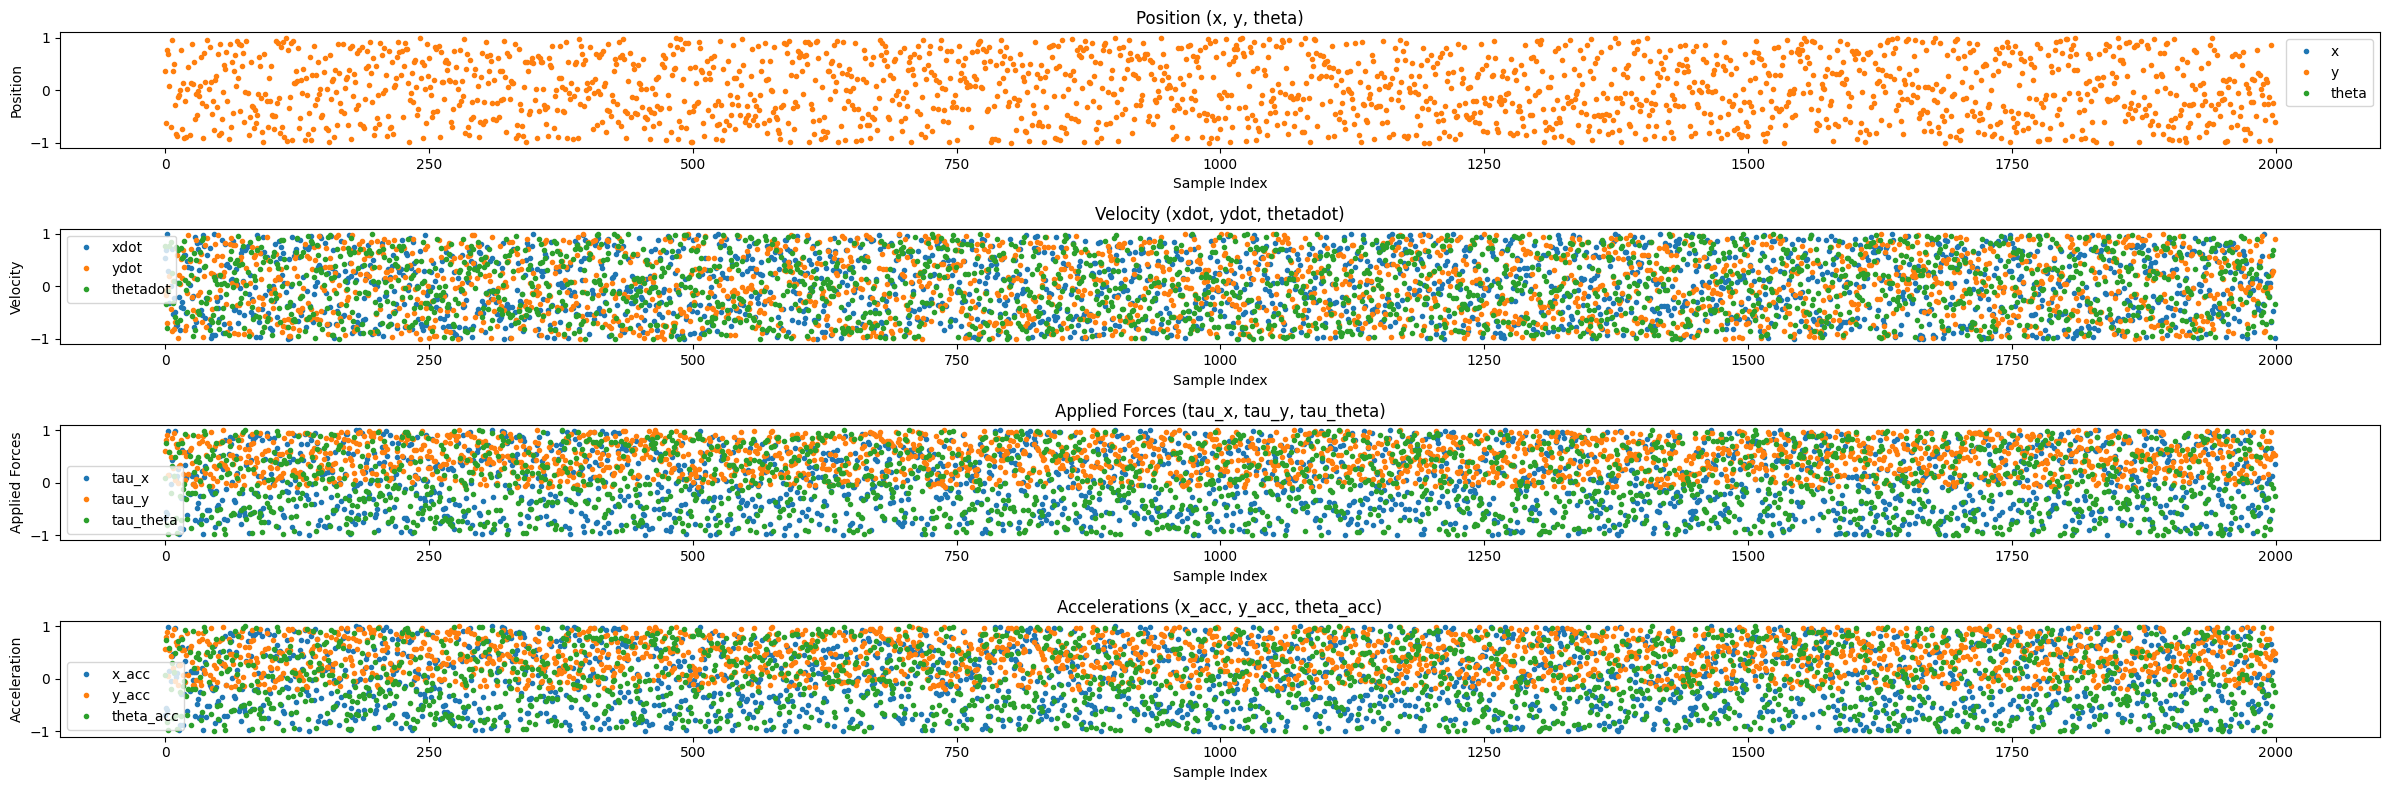

[ 0.    99.872  0.   ]
[49.993 49.978 24.987]
[ 19.982 109.892   4.995]
[ 19.982 100.082 299.699]


In [57]:
import matplotlib.pyplot as plt

slc_idx = 2000
res = results

plt.figure(figsize=(24, 8))
plt.subplot(4, 1, 1)
plt.plot(res[:slc_idx, :3]/np.max(res[:slc_idx, :3], axis=0), linestyle='none', marker='.')
plt.title('Position (x, y, theta)')
plt.xlabel('Sample Index')
plt.ylabel('Position')
plt.legend(['x', 'y', 'theta'])
plt.subplot(4, 1, 2)
plt.plot(res[:slc_idx, 3:6]/np.max(res[:slc_idx, 3:6], axis=0), linestyle='none', marker='.')
plt.title('Velocity (xdot, ydot, thetadot)')
plt.xlabel('Sample Index')
plt.ylabel('Velocity')
plt.legend(['xdot', 'ydot', 'thetadot'])
plt.subplot(4, 1, 3)
plt.plot(res[:slc_idx, 6:9]/np.max(res[:slc_idx, 6:9], axis=0), linestyle='none', marker='.')
plt.title('Applied Forces (tau_x, tau_y, tau_theta)')
plt.xlabel('Sample Index')
plt.ylabel('Applied Forces')
plt.legend(['tau_x', 'tau_y', 'tau_theta'])
plt.subplot(4, 1, 4)
plt.plot(res[:slc_idx, 9:12]/np.max(res[:slc_idx, 9:12], axis=0), linestyle='none', marker='.')
plt.title('Accelerations (x_acc, y_acc, theta_acc)')
plt.xlabel('Sample Index')
plt.ylabel('Acceleration')
plt.legend(['x_acc', 'y_acc', 'theta_acc'])
plt.tight_layout()
plt.show()

for i in range(4):
    print(np.max(res[:slc_idx, i*3:(i+1)*3], axis=0))

with open('block_simulation_sample.pkl', 'wb') as f:
    pickle.dump(results, f)

In [ ]:
xml_path = "/home/clown2/Desktop/Work/Research/afil-project/sim/block_model.xml"

model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)
dt = model.opt.timestep
sim_time = 200.0 
num_steps = int(sim_time / dt)

simulation_data = {
    'time': [],
    'position': [], 
    'velocity': [],
    'acceleration': [],
    'control': [],
}
    
for step in range(num_steps):
    
    t = data.time

    current_time = step * dt
    data.qfrc_applied[:] = control_signal
    current_pose = data.qpos.copy()
    mujoco.mj_forward(model, data)
    current_vel = data.qvel.copy()
    current_acc = data.qacc.copy()
    
    if step > 1:
        simulation_data['time'].append(current_time)
        current_pose[2] = ((current_pose[2] + np.pi) % (2*np.pi)) - np.pi
        simulation_data['position'].append(current_pose)
        simulation_data['velocity'].append(current_vel)
        simulation_data['acceleration'].append(current_acc)
        simulation_data['control'].append(control_signal)

    # viewer.sync()
        
    if step % 100 == 0:
        # p_term, i_term, d_term = components
        print(f"Step: {step}, Time: {current_time:.2f}s", end="\r")
    
    # Slow down simulation for better visualization
    # time.sleep(0.005) 

print("Simulation complete.")
# Keep the viewer open for a moment to see the final state
# time.sleep(2.0)

for key in ['time', 'position', 'velocity', 'acceleration', 'control']:
    simulation_data[key] = np.array(simulation_data[key])
output_file = 'block_simulation_data.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(simulation_data, f)

print(f"Simulation data saved to {output_file}")

Max position: [ 4.13886527 21.35424235  3.14157043]
Max target: [ 1.          1.         12.56637061]
Max velocity: [ 6.06404172 45.50028497 11.39441365]
Max acceleration: [  9.51408695 100.05790568  60.04700271]
Max control: [  9.51408695 109.86790568   1.00078338]


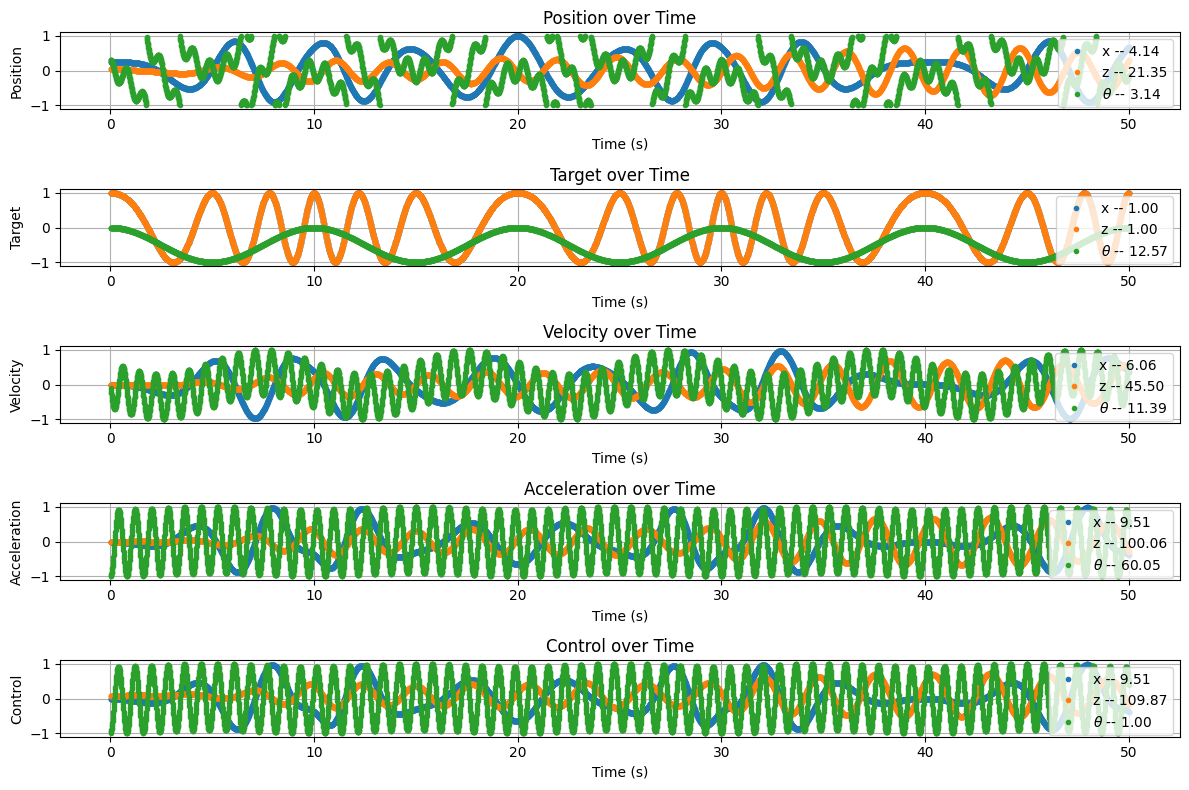

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
keys = ['position', 
        'target', 
        'velocity', 
        'acceleration', 
        'control']
for i, key in enumerate(keys):
    val_max = np.max(np.abs(simulation_data[key]), axis=0)

    # import pdb; pdb.set_trace()

    print(f"Max {key}: {val_max.copy()}")
    sim_key = np.array(simulation_data[key]) / val_max.copy()

    # np.random.shuffle(sim_key)

    plt.subplot(len(keys), 1, i + 1)
    # slice_idx = len(simulation_data['time'])
    # slice_start_idx = 1900
    # slice_idx = 1960
    slice_start_idx = 0
    slice_idx = 5000
    plt.plot(simulation_data['time'][slice_start_idx:slice_idx], 
             sim_key[slice_start_idx:slice_idx,:], linestyle='None', marker='.')
    plt.title(f'{key.capitalize()} over Time')
    plt.xlabel('Time (s)')
    plt.ylabel(key.capitalize())
    plt.legend([f'x -- {val_max[0]:.2f}', 
                f'z -- {val_max[1]:.2f}', 
                fr'$\theta$ -- {val_max[2]:.2f}'], loc='upper right')
    plt.grid()
plt.tight_layout()


Text(0.5, 1.0, 'Chirp Signal')

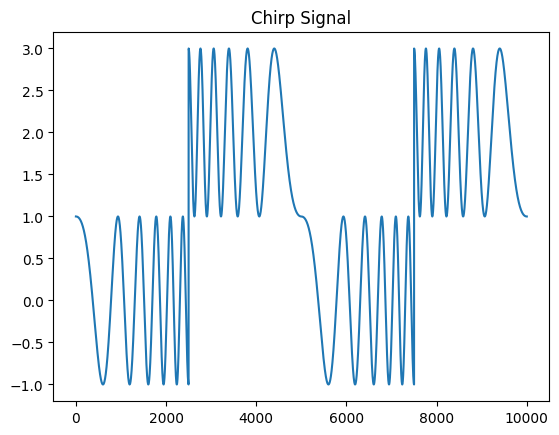

In [ ]:
# import scipy

# chirp_out = []

# def chirp_loop(t, f0, f1, t1):
#     chirp = scipy.signal.chirp(t, f0=f0, f1=f1, t1=t1, method='linear')
#     return chirp

# for t in np.linspace(0, 40, 10000):
#     # chirp = scipy.signal.chirp(t, f0=0.1, f1=0.5, t1=10, method='linear')
#     if t % 20 < 10:
#         chirp = scipy.signal.chirp(t%20, f0=0.1, f1=1, t1=10)
#     else:
#         chirp = 2+scipy.signal.chirp((t%20)-10, f0=1, f1=0.1, t1=10)
#     # chirp = chirp_loop(t, 10)
#     chirp_out.append(chirp)

# import matplotlib.pyplot as plt
# plt.plot(chirp_out)
# plt.title('Chirp Signal')